In [59]:
## Attribution
## LST preprocessing and multi‑year time‑series extraction for Dhaka (2014–2024).
## This workflow follows established Landsat thermal processing practices and is informed by
## Mohiuddin & Mund (2024), including cloud masking, radiometric calibration, spectral indices,
## FVC‑based emissivity estimation, atmospheric correction, and single‑channel LST retrieval
## (Jiménez‑Muñoz et al., 2008; 2014).
##
## The script merges Landsat 8/9 collections, applies water‑vapour correction, computes LST for
## all valid scenes, and extracts descriptive statistics to generate a clean LST time series.
##
## Dhaka‑specific parameterization and implementation were developed by Mahbubul Alam.


In [ ]:
# installing libraries
!pip install geemap --upgrade
!pip install geopandas
!pip install osmnx
!pip install vl-convert-python


In [129]:
# loading necessary libraries
import os
import sys
import ee
import geemap
import osmnx as ox
import geopandas as gpd
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import altair as alt
alt.renderers.enable('png')


RendererRegistry.enable('png')

In [97]:
ee.Authenticate()
ee.Initialize(project='ee-sanim')


In [98]:

#study period
year_start = 2014
year_end = 2024
month_start = 1
month_end = 12

# temperature threshold
t_threshold = 20

# cloud filter
max_cloud_cover = 60 # in percentage

aoi = 'projects/ee-sanim/assets/Coredhaka'
roi = ee.FeatureCollection(aoi)

# Min and max NDVI values
ndvi_v = 0.86
ndvi_s = -0.64

# emissivity value (Li et al., 2013)
epsilon_v = 0.985
epsilon_s = 0.97
epsilon_w = 0.99

# coefficients for atmospheric functions (Jiménez‐Muñoz et al. (2008) & Jiménez‐Muñoz et al. (2014))
cs_l8 = [0.04019, 0.02916, 1.01523,
         -0.38333, -1.50294, 0.20324,
         0.00918, 1.36072, -0.27514]
cs_l9 = [0.06518, 0.00683, 1.02717,
         -0.53003, -1.25866, 0.10490,
         -0.01965, 1.36947, -0.24310]


Map = geemap.Map()
Map.centerObject(roi, 10)
Map.addLayer(roi, {}, "Dhaka AOI")
Map

Map(center=[23.789102582046304, 90.4166173461112], controls=(WidgetControl(options=['position', 'transparent_b…

In [99]:
## Rename bands and clipping
# renaming bands
def fun_bands_l57(img):
       bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B7']
       thermal_band = ['B6']
       new_bands = ['B', 'G', 'R', 'NIR', 'SWIR1', 'SWIR2']
       new_thermal_bands = ['TIR']
       vnirswir = img.select(bands).multiply(0.0001).rename(new_bands)
       tir = img.select(thermal_band).multiply(0.1).rename(new_thermal_bands)
       return vnirswir.addBands(tir).copyProperties(img, ['system:time_start'])


def fun_bands_l8(img):
       bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7']
       thermal_band = ['B10']
       new_bands = ['B', 'G', 'R', 'NIR', 'SWIR1', 'SWIR2']
       new_thermal_bands = ['TIR']
       vnirswir = img.select(bands).multiply(0.0001).rename(new_bands)
       tir = img.select(thermal_band).multiply(0.1).rename(new_thermal_bands)
       return vnirswir.addBands(tir).copyProperties(img, ['system:time_start'])

#clipping
def fun_clip(img):
  clip_img = img.clip(roi)
  return clip_img


In [100]:
## Masking
# Function to cloud mask Landsat TM, ETM+, OLI_TIRS Surface Reflectance Products (Foga et al., 2017)
def fun_mask_ls_sr(img):
       cloudShadowBitMask = ee.Number(2).pow(3).int()
       cloudsBitMask = ee.Number(2).pow(5).int()
       snowBitMask = ee.Number(2).pow(4).int()
       qa = img.select('pixel_qa')
       mask = qa.bitwiseAnd(cloudShadowBitMask).eq(0).And(
              qa.bitwiseAnd(cloudsBitMask).eq(0)).And(
              qa.bitwiseAnd(snowBitMask).eq(0))
       return img.updateMask(mask)

# Function to mask LST below certain temperature threshold
def fun_mask_T(img):
    mask = img.select('LST').gt(t_threshold)
    return img.updateMask(mask)

In [101]:
## Matching and calibration
# Radiometric Calibration
def fun_radcal(img):
    radiance = ee.Algorithms.Landsat.calibratedRadiance(img).rename('RADIANCE')
    return img.addBands(radiance)

# L to ee.Image
def fun_l_addband(img):
    l = ee.Image(img.get('L')).select('RADIANCE').rename('L')
    return img.addBands(l)

# Create maxDifference-filter to match TOA and SR products
maxDiffFilter = ee.Filter.maxDifference(
    difference=2 * 24 * 60 * 60 * 1000,
    leftField= 'system:time_start',
    rightField= 'system:time_start'
)

# Define join: Water vapor
join_wv = ee.Join.saveBest(
    matchKey = 'WV',
    measureKey = 'timeDiff'
)

# Define join: Radiance
join_l = ee.Join.saveBest(
    matchKey = 'L',
    measureKey = 'timeDiff'
)

In [102]:
## Spectral Indices
# NDVI (Rouse et al., 1973)
def fun_ndvi(img):
    ndvi = img.normalizedDifference(['NIR', 'R']).rename('NDVI')
    return img.addBands(ndvi)

#MNDWI (Xu, 2006)
def fun_mndwi(img):
    mndwi = img.normalizedDifference(['G', 'SWIR1']).rename('MNDWI')
    return img.addBands(mndwi)

# IBI (Xu, 2008)
def fun_ibi(img):
    const = ee.Number(2)

    ibi = img.expression(
        '(((const * swir1) / (swir1 + nir))-((nir / (nir + red)) + (green / (green + swir1))))   / (((const * swir1) / (swir1 + nir))+((nir / (nir + red)) + (green / (green + swir1))))',
        {
            'swir1': img.select('SWIR1'),
            'nir': img.select('NIR'),
            'red': img.select('R'),
            'green': img.select('G'),
            'const': const
        }).rename('IBI')
    return img.addBands(ibi)

# Parameter calculation
# Fraction Vegetation Cover (FVC) (Carlson & Ripley, 1997)
def fun_fvc(img):
    fvc = img.expression(
        '((NDVI-NDVI_s)/(NDVI_v-NDVI_s))**2',
        {
            'NDVI': img.select('NDVI'),
            'NDVI_s': ndvi_s,
            'NDVI_v': ndvi_v
        }
    ).rename('FVC')
    return img.addBands(fvc)

# emissivity (Sobrino et al., 2008)
# scale Emissivity (Epsilon) between NDVI_s and NDVI_v
def fun_epsilon_scale(img):
    epsilon_scale = img.expression(
        'epsilon_s+(epsilon_v-epsilon_s)*FVC',
        {
            'FVC': img.select('FVC'),
            'epsilon_s': epsilon_s,
            'epsilon_v': epsilon_v
        }
    ).rename('EPSILON_SCALE')
    return img.addBands(epsilon_scale)

In [103]:
# emissivity (Epsilon)
def fun_epsilon(img):
    pseudo = img.select(['NDVI']).set('system:time_start', img.get('system:time_start'))
    epsilon = pseudo.where(img.expression('NDVI > NDVI_v',
                                          {'NDVI': img.select('NDVI'),
                                           'NDVI_v': ndvi_v}), epsilon_v)
    epsilon = epsilon.where(img.expression('NDVI < NDVI_s && NDVI >= 0',
                                           {'NDVI': img.select('NDVI'),
                                            'NDVI_s': ndvi_s}), epsilon_s)
    epsilon = epsilon.where(img.expression('NDVI < 0',
                                           {'NDVI': img.select('NDVI')}), epsilon_w)
    epsilon = epsilon.where(img.expression('NDVI <= NDVI_v && NDVI >= NDVI_s',
                                           {'NDVI': img.select('NDVI'),
                                            'NDVI_v': ndvi_v,
                                            'NDVI_s': ndvi_s}), img.select('EPSILON_SCALE')).rename('EPSILON')
    return img.addBands(epsilon)

# Function to scale WV content product (Lantz et al., 2010)
def fun_wv_scale(img):
    wv_scaled = ee.Image(img.get('WV')).multiply(0.1).rename('WV_SCALED')
    wv_scaled = wv_scaled.resample('bilinear')
    return img.addBands(wv_scaled)

In [104]:
## Land surface temperature calculation
# Atmospheric Functions (Lantz et al., 2010 & Jiménez-Muñoz et al., 2014)
def fun_af1(cs):
    def wrap(img):
        af1 = img.expression(
            '('+str(cs[0])+'*(WV**2))+('+str(cs[1])+'*WV)+('+str(cs[2])+')',
            {
                'WV': img.select('WV_SCALED')
            }
        ).rename('AF1')
        return img.addBands(af1)
    return wrap


def fun_af2(cs):
    def wrap(img):
        af2 = img.expression(
            '('+str(cs[3])+'*(WV**2))+('+str(cs[4])+'*WV)+('+str(cs[5])+')',
            {
                'WV': img.select('WV_SCALED')
            }
        ).rename('AF2')
        return img.addBands(af2)
    return wrap

def fun_af3(cs):
    def wrap(img):
        af3 = img.expression(
            '('+str(cs[6])+'*(WV**2))+('+str(cs[7])+'*WV)+('+str(cs[8])+')',
            {
                'WV': img.select('WV_SCALED')
            }
        ).rename('AF3')
        return img.addBands(af3)
    return wrap

    # Gamma Functions
def fun_gamma_l8(img):
    gamma = img.expression('(BT**2)/(1324*L)',
                           {'BT': img.select('TIR'),
                            'L': img.select('L')
                            }).rename('GAMMA')
    return img.addBands(gamma)


def fun_gamma_l7(img):
    gamma = img.expression('(BT**2)/(1277*L)',
                           {'BT': img.select('TIR'),
                            'L': img.select('L')
                            }).rename('GAMMA')
    return img.addBands(gamma)


def fun_gamma_l5(img):
    gamma = img.expression('(BT**2)/(1256*L)',
                           {'BT': img.select('TIR'),
                            'L': img.select('L')
                            }).rename('GAMMA')
    return img.addBands(gamma)
    # Delta Functions
def fun_delta_l8(img):
    delta = img.expression('BT-((BT**2)/1324)',
                           {'BT': img.select('TIR')
                            }).rename('DELTA')
    return img.addBands(delta)


def fun_delta_l7(img):
    delta = img.expression('BT-((BT**2)/1277)',
                           {'BT': img.select('TIR')
                            }).rename('DELTA')
    return img.addBands(delta)


def fun_delta_l5(img):
    delta = img.expression('BT-((BT**2)/1256)',
                           {'BT': img.select('TIR')
                            }).rename('DELTA')
    return img.addBands(delta)
# Land Surface Temperature (Jimenez-Munoz et al., 2008)
def fun_lst(img):
    lst = img.expression(
        '(GAMMA*(((1/EPSILON)*(AF1*L+AF2))+AF3)+DELTA)-273.15',
        {
            'GAMMA': img.select('GAMMA'),
            'DELTA': img.select('DELTA'),
            'EPSILON': img.select('EPSILON'),
            'AF1': img.select('AF1'),
            'AF2': img.select('AF2'),
            'AF3': img.select('AF3'),
            'L': img.select('L')
        }
    ).rename('LST')
    return img.addBands(lst)

def fun_mask_lst(img):
    mask = img.select('LST').gt(t_threshold)
    return img.updateMask(mask)
	## Descriptive statistics extraction and date variables
#function for extracting image info
def fctn_get_image_stats(img):
  img_lst = img.select('LST')

  img_lst_mean_value = img_lst.reduceRegion(ee.Reducer.mean(), roi, 30,  crs = 'EPSG:32648', bestEffort = True, maxPixels = 1e9).getInfo()['LST']
  img_lst_max_value = img_lst.reduceRegion(ee.Reducer.max(), roi, 30,  crs = 'EPSG:32648', bestEffort = True, maxPixels = 1e9).getInfo()['LST']
  img_lst_min_value = img_lst.reduceRegion(ee.Reducer.min(), roi, 30,  crs = 'EPSG:32648', bestEffort = True, maxPixels = 1e9).getInfo()['LST']

  img_date = img.date().getInfo()['value']

  img_sytemindex = img.get('system:index').getInfo()

  img_cloud_cover = img.get('L')
  img_cloud_cover = ee.Image(img_cloud_cover)
  img_cloud_cover = img_cloud_cover.get('CLOUD_COVER')
    # print(img_cloud_cover)

  img_all_info = {
      'system:index': img_sytemindex,
      'date': img_date,
      'mean_lst' : img_lst_mean_value,
      'min_lst' : img_lst_min_value,
      'max_lst' : img_lst_max_value,
      'cloud_cover': img_cloud_cover
  }
  return img_all_info

  # Function to add date variables to DataFrame.
def add_date_info(df):
  df['Timestamp'] = pd.to_datetime(df['Millis'], unit='ms')
  df['Year'] = pd.DatetimeIndex(df['Timestamp']).year
  df['Month'] = pd.DatetimeIndex(df['Timestamp']).month
  df['Day'] = pd.DatetimeIndex(df['Timestamp']).day
  df['DOY'] = pd.DatetimeIndex(df['Timestamp']).dayofyear
  return df


In [105]:
### Calling the image collections

# --- Landsat 8 OLI-TIRS ---
imgCol_L8_TOA = ee.ImageCollection('LANDSAT/LC08/C01/T1')\
    .filterBounds(roi)\
    .filter(ee.Filter.calendarRange(year_start, year_end, 'year'))\
    .filter(ee.Filter.calendarRange(month_start, month_end, 'month'))\
    .filter(ee.Filter.lt('CLOUD_COVER', max_cloud_cover))\
    .select(['B10'])

imgCol_L8_SR = ee.ImageCollection('LANDSAT/LC08/C01/T1_SR')\
    .filterBounds(roi)\
    .filter(ee.Filter.calendarRange(year_start, year_end, 'year'))\
    .filter(ee.Filter.calendarRange(month_start, month_end, 'month'))\
    .filter(ee.Filter.lt('CLOUD_COVER', max_cloud_cover))\
    .map(fun_mask_ls_sr)\
    .map(fun_bands_l8)

# --- Landsat 9 OLI-TIRS ---
imgCol_L9_TOA = ee.ImageCollection('LANDSAT/LC09/C01/T1')\
    .filterBounds(roi)\
    .filter(ee.Filter.calendarRange(year_start, year_end, 'year'))\
    .filter(ee.Filter.calendarRange(month_start, month_end, 'month'))\
    .filter(ee.Filter.lt('CLOUD_COVER', max_cloud_cover))\
    .select(['B10'])

imgCol_L9_SR = ee.ImageCollection('LANDSAT/LC09/C01/T1_SR')\
    .filterBounds(roi)\
    .filter(ee.Filter.calendarRange(year_start, year_end, 'year'))\
    .filter(ee.Filter.calendarRange(month_start, month_end, 'month'))\
    .filter(ee.Filter.lt('CLOUD_COVER', max_cloud_cover))\
    .map(fun_mask_ls_sr)\
    .map(fun_bands_l8)  # same as L8

# --- Merge Landsat 8 & 9 Collections ---
merged_TOA = imgCol_L8_TOA.merge(imgCol_L9_TOA)
merged_SR  = imgCol_L8_SR.merge(imgCol_L9_SR)

# --- Optional: NCEP/NCAR Water Vapor ---
imgCol_WV = ee.ImageCollection('NCEP_RE/surface_wv')\
    .filterBounds(roi)\
    .filter(ee.Filter.calendarRange(year_start, year_end, 'year'))\
    .filter(ee.Filter.calendarRange(month_start, month_end, 'month'))


In [106]:
### Calculation of LST and other indices

# --- TOA (Radiance) ---
imgCol_L8_TOA = imgCol_L8_TOA.map(fun_radcal)
imgCol_L9_TOA = imgCol_L9_TOA.map(fun_radcal)

# --- Join SR with TOA using temporal filter ---
imgCol_L8_SR = ee.ImageCollection(join_l.apply(imgCol_L8_SR, imgCol_L8_TOA, maxDiffFilter))
imgCol_L9_SR = ee.ImageCollection(join_l.apply(imgCol_L9_SR, imgCol_L9_TOA, maxDiffFilter))

# --- Add additional bands if required ---
imgCol_L8_SR = imgCol_L8_SR.map(fun_l_addband)
imgCol_L9_SR = imgCol_L9_SR.map(fun_l_addband)

# --- Join with Water Vapor ---
imgCol_L8_SR = ee.ImageCollection(join_wv.apply(imgCol_L8_SR, imgCol_WV, maxDiffFilter))
imgCol_L9_SR = ee.ImageCollection(join_wv.apply(imgCol_L9_SR, imgCol_WV, maxDiffFilter))

# --- Scale Water Vapor ---
imgCol_L8_SR = imgCol_L8_SR.map(fun_wv_scale)
imgCol_L9_SR = imgCol_L9_SR.map(fun_wv_scale)

# --- Atmospheric Correction Functions ---
imgCol_L8_SR = imgCol_L8_SR.map(fun_af1(cs_l8))\
                           .map(fun_af2(cs_l8))\
                           .map(fun_af3(cs_l8))

imgCol_L9_SR = imgCol_L9_SR.map(fun_af1(cs_l8))\
                           .map(fun_af2(cs_l8))\
                           .map(fun_af3(cs_l8))  # same coefficients as L8

# --- Delta and Gamma Functions ---
imgCol_L8_SR = imgCol_L8_SR.map(fun_delta_l8).map(fun_gamma_l8)
imgCol_L9_SR = imgCol_L9_SR.map(fun_delta_l8).map(fun_gamma_l8)

# --- Merge L8 & L9 ---
imgCol_merge = imgCol_L8_SR.merge(imgCol_L9_SR).sort('system:time_start')

# --- Clip to ROI ---
imgCol_merge = imgCol_merge.map(fun_clip)

# --- Indices and Parameters ---
imgCol_merge = imgCol_merge.map(fun_ndvi)\
                           .map(fun_ibi)\
                           .map(fun_mndwi)\
                           .map(fun_fvc)\
                           .map(fun_epsilon_scale)\
                           .map(fun_epsilon)

# --- LST Calculation ---
imgCol_merge = imgCol_merge.map(fun_lst)\
                           .map(fun_mask_lst)


In [107]:


# Cloud cover limit
max_cloud_cover = 60  # in %

# Function 1: Cloud masking using CFMask
def function_mask_clouds_l89(img):
    cloud_mask = img.select('QA_PIXEL').bitwiseAnd(1 << 3).eq(0)
    return img.updateMask(cloud_mask)


# Calling the image collections
# Landsat 8
# Surface Reflectance (SR) Collection (Level 2, Collection 2, Tier 1)
imgCol_L8_SR = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')\
    .filterBounds(roi)\
    .filter(ee.Filter.calendarRange(year_start,year_end,'year'))\
    .filter(ee.Filter.calendarRange(month_start,month_end,'month'))\
    .filter(ee.Filter.lt('CLOUD_COVER', max_cloud_cover))\
    .map(function_mask_clouds_l89)

size_L8_SR = imgCol_L8_SR.size()
print("Total LS 8 collection SR: ",size_L8_SR.getInfo())

# Landsat 9
# Surface Reflectance (SR) Collection (Level 2, Collection 2, Tier 1)
imgCol_L9_SR = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')\
    .filterBounds(roi)\
    .filter(ee.Filter.calendarRange(year_start,year_end,'year'))\
    .filter(ee.Filter.calendarRange(month_start,month_end,'month'))\
    .filter(ee.Filter.lt('CLOUD_COVER', max_cloud_cover))\
    .map(function_mask_clouds_l89)

size_L9_SR = imgCol_L9_SR.size()
print("Total LS 9 collection SR: ",size_L9_SR.getInfo())

Total LS 8 collection SR:  310
Total LS 9 collection SR:  89


In [108]:
# Function 2: Renaming bands for coherence and and applying scale factors and offset
def function_bands_l89(img):
       bands = ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
       thermal_band = ['ST_B10']
       new_bands = ['B', 'G', 'R', 'NIR', 'SWIR1', 'SWIR2']
       new_thermal_bands = ['LST']
       vnirswir = img.select(bands).multiply(0.0000275).add(-0.2).rename(new_bands)
       tir = img.select(thermal_band).multiply(0.00341802).add(149).subtract(273.15).rename(new_thermal_bands) # converting it from K to celcius by subtracting 273.15
       return vnirswir.addBands(tir).copyProperties(img, img.propertyNames())

# Applying the band coherence function and scale factors
imgCol_merge_L8_band_coh = imgCol_L8_SR.map(function_bands_l89)
imgCol_merge_L9_band_coh = imgCol_L9_SR.map(function_bands_l89)


"""***5. Clipping the collections to the area of interest (AOI)***"""
# Function 3: clipping the image collections to study area
def fun_clip(img):
  clip_img = img.clip(roi)
  return clip_img

# Applying clip function
imgCol_merge_L8_band_coh_clip = imgCol_merge_L8_band_coh.map(fun_clip)
imgCol_merge_L9_band_coh_clip = imgCol_merge_L9_band_coh.map(fun_clip)

In [109]:
"""***6. Merging the image collections into one collection***"""

# Merging the collection
imgCol_merge = imgCol_merge_L8_band_coh_clip.merge(imgCol_merge_L9_band_coh_clip)

imgCol_merge

Output hidden; open in https://colab.research.google.com to view.

In [110]:
# Function 4: Extracting the tabular information from the processed images
def fctn_get_image_stats(img):
    img_lst = img.select('LST')

    # Calculate basic statistics
    img_lst_mean_value = img_lst.reduceRegion(ee.Reducer.mean(), roi, 30, crs='EPSG:4326', bestEffort=True, maxPixels=1e9).getInfo().get('LST')
    img_lst_max_value = img_lst.reduceRegion(ee.Reducer.max(), roi, 30, crs='EPSG:4326', bestEffort=True, maxPixels=1e9).getInfo().get('LST')
    img_lst_min_value = img_lst.reduceRegion(ee.Reducer.min(), roi, 30, crs='EPSG:4326', bestEffort=True, maxPixels=1e9).getInfo().get('LST')

    # get metadata
    img_date = img.date().getInfo().get('value')
    img_systemindex = img.get('system:index').getInfo()
    img_cloud_cover = img.get('CLOUD_COVER').getInfo()
    img_spacecraft = img.get('SPACECRAFT_ID').getInfo()

    # Create dictionary with all information
    img_all_info = {
        'system:index': img_systemindex,
        'date': img_date,
        'mean_lst': img_lst_mean_value,
        'min_lst': img_lst_min_value,
        'max_lst': img_lst_max_value,
        'cloud_cover': img_cloud_cover,
        'satellite': img_spacecraft
    }

    return img_all_info


In [111]:
# Converting image collection to list
doi = imgCol_merge
doiList = doi.toList(doi.size())
doiList_size = doiList.size().getInfo()
print('Total Images in Data of Interest (doi) dataset: ', doiList_size)


Total Images in Data of Interest (doi) dataset:  399


In [112]:
# Extracting the tabular information from the processed images
def fctn_get_image_stats(img):
    img_lst = img.select('LST')

    # Calculate basic statistics
    img_lst_mean_value = img_lst.reduceRegion(ee.Reducer.mean(), roi, 30, crs='EPSG:4326', bestEffort=True, maxPixels=1e9).getInfo().get('LST')
    img_lst_max_value = img_lst.reduceRegion(ee.Reducer.max(), roi, 30, crs='EPSG:4326', bestEffort=True, maxPixels=1e9).getInfo().get('LST')
    img_lst_min_value = img_lst.reduceRegion(ee.Reducer.min(), roi, 30, crs='EPSG:4326', bestEffort=True, maxPixels=1e9).getInfo().get('LST')

    # get metadata
    img_date = img.date().getInfo().get('value')
    img_systemindex = img.get('system:index').getInfo()
    img_cloud_cover = img.get('CLOUD_COVER').getInfo()
    img_spacecraft = img.get('SPACECRAFT_ID').getInfo()

    # Create dictionary with all information
    img_all_info = {
        'system:index': img_systemindex,
        'date': img_date,
        'mean_lst': img_lst_mean_value,
        'min_lst': img_lst_min_value,
        'max_lst': img_lst_max_value,
        'cloud_cover': img_cloud_cover,
        'satellite': img_spacecraft
    }

    return img_all_info

In [113]:
#  Optimized extraction - returns a feature with all properties
import time  # Just add this import
from tqdm import tqdm
import pandas as pd
#  Optimized extraction - returns a feature with all properties
def fctn_get_image_stats_batch(img):
    img_lst = img.select('LST')

    # Calculate ALL statistics in ONE reduceRegion call
    stats = img_lst.reduceRegion(
        reducer=ee.Reducer.mean().combine(
            reducer2=ee.Reducer.max(),
            sharedInputs=True
        ).combine(
            reducer2=ee.Reducer.min(),
            sharedInputs=True
        ),
        geometry=roi,
        scale=30,
        crs='EPSG:4326',
        bestEffort=True,
        maxPixels=1e9
    )

    # Get metadata as EE objects
    return ee.Feature(None, {
        'system_index': img.get('system:index'),
        'date': img.date().millis(),
        'mean_lst': stats.get('LST_mean'),
        'max_lst': stats.get('LST_max'),
        'min_lst': stats.get('LST_min'),
        'cloud_cover': img.get('CLOUD_COVER'),
        'satellite': img.get('SPACECRAFT_ID')
    })

print("Starting batch extraction of all images...")

# Convert image collection to feature collection
features = doi.map(fctn_get_image_stats_batch)

# Get ALL results in ONE SINGLE call (key optimization!)
print("Downloading all results in one batch...")
start_time = time.time()
data_list = features.getInfo()['features']
download_time = time.time() - start_time

print(f"Downloaded {len(data_list)} records in {download_time:.2f} seconds")

# Convert to DataFrame
rows = []
for feature in tqdm(data_list, desc="Converting to DataFrame"):
    props = feature['properties']
    rows.append({
        'SystemIndex': props['system_index'],
        'Millis': props['date'],
        'MeanLST': props['mean_lst'],
        'MaxLST': props['max_lst'],
        'MinLST': props['min_lst'],
        'Cloud': props['cloud_cover'],
        'satellite': props['satellite']
    })

df = pd.DataFrame(rows)
print(f"Created DataFrame with {len(df)} rows")

# Continue with your date processing
# Function 5: Add date variables to DataFrame.
def add_date_info(df):
    df['Timestamp'] = pd.to_datetime(df['Millis'], unit='ms')
    df['Year'] = pd.DatetimeIndex(df['Timestamp']).year
    df['Month'] = pd.DatetimeIndex(df['Timestamp']).month
    df['Day'] = pd.DatetimeIndex(df['Timestamp']).day
    df['DOY'] = pd.DatetimeIndex(df['Timestamp']).dayofyear
    return df

# Adding the date variables
df = add_date_info(df)

print(df.head())
print(f"\nTotal processing time: {(time.time() - start_time):.2f} seconds")

Starting batch extraction of all images...
Downloaded 399 records in 3.57 seconds


Converting to DataFrame: 100%|██████████| 399/399 [00:00<00:00, 364602.90it/s]

Created DataFrame with 399 rows
              SystemIndex         Millis    MeanLST     MaxLST     MinLST  \
0  1_LC08_137043_20140125  1390623932843  27.440536  36.777218  21.508922   
1  1_LC08_137043_20140210  1392006320394  28.919461  37.990615  20.046010   
2  1_LC08_137043_20140226  1393388707600  29.007015  39.521888  22.161764   
3  1_LC08_137043_20140314  1394771096612  35.752246  46.751000  25.374703   
4  1_LC08_137043_20140330  1396153479275  41.314555  53.624638  30.272726   

   Cloud  satellite               Timestamp  Year  Month  Day  DOY  
0   3.56  LANDSAT_8 2014-01-25 04:25:32.843  2014      1   25   25  
1  41.45  LANDSAT_8 2014-02-10 04:25:20.394  2014      2   10   41  
2   2.21  LANDSAT_8 2014-02-26 04:25:07.600  2014      2   26   57  
3  11.15  LANDSAT_8 2014-03-14 04:24:56.612  2014      3   14   73  
4   0.34  LANDSAT_8 2014-03-30 04:24:39.275  2014      3   30   89  

Total processing time: 3.60 seconds


In [114]:
# mounting the google dirive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [115]:
# setting the working directory
os.chdir('/content/drive/MyDrive/ARS/Scientific_Project')
print("Current working directory: {0}".format(os.getcwd()))



Current working directory: /content/drive/MyDrive/ARS/Scientific_Project


In [116]:
# export the dataframe to a CSV file
df.to_csv('lsttimeseries.csv', index=False)

# Function 6: Loading the csv/txt file
def load_csv(filepath):
    data =  []
    col = []
    checkcol = False
    with open(filepath) as f:
        for val in f.readlines():
            val = val.replace("\n","")
            val = val.split(',')
            if checkcol is False:
                col = val
                checkcol = True
            else:
                data.append(val)
    df = pd.DataFrame(data=data, columns=col)

    return df

# Loading the data
myData = load_csv('lsttimeseries.csv')
df = myData
print(df.head())

              SystemIndex         Millis             MeanLST  \
0  1_LC08_137043_20140125  1390623932843   27.44053583299265   
1  1_LC08_137043_20140210  1392006320394  28.919461092191554   
2  1_LC08_137043_20140226  1393388707600  29.007015499722442   
3  1_LC08_137043_20140314  1394771096612  35.752246498584526   
4  1_LC08_137043_20140330  1396153479275   41.31455461206236   

               MaxLST              MinLST  Cloud  satellite  \
0         36.77721764  21.508922299999995   3.56  LANDSAT_8   
1   37.99061474000001  20.046009740000045  41.45  LANDSAT_8   
2   39.52188769999998  22.161764120000043   2.21  LANDSAT_8   
3  46.750999999999976  25.374702920000004  11.15  LANDSAT_8   
4   53.62463822000001  30.272725580000042   0.34  LANDSAT_8   

                 Timestamp  Year Month Day DOY  
0  2014-01-25 04:25:32.843  2014     1  25  25  
1  2014-02-10 04:25:20.394  2014     2  10  41  
2  2014-02-26 04:25:07.600  2014     2  26  57  
3  2014-03-14 04:24:56.612  2014     3  

In [117]:
import os

filename = 'landsat_lst_timeseries.csv'

if os.path.exists(filename):
    print(f"File '{filename}' already exists.")
    user_input = input("Overwrite? (yes/no): ")
    if user_input.lower() != 'yes':
        # Create a new filename with timestamp
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'landsat_lst_timeseries_{timestamp}.csv'
        print(f"Using new filename: {filename}")

df.to_csv(filename, index=False)
print(f"Data successfully saved to '{filename}'")
print(f"File contains {len(df)} rows and {len(df.columns)} columns")

File 'landsat_lst_timeseries.csv' already exists.
Overwrite? (yes/no): no
Using new filename: landsat_lst_timeseries_20260130_214927.csv
Data successfully saved to 'landsat_lst_timeseries_20260130_214927.csv'
File contains 399 rows and 12 columns


In [118]:
# Converting the variables into numeric
#Mean
df["MeanLST"] = pd.to_numeric(df["MeanLST"])
meanlst = df["MeanLST"]

#Max
df["MaxLST"] = pd.to_numeric(df["MaxLST"])
maxlst = df["MaxLST"]

#Min
df["MinLST"] = pd.to_numeric(df["MinLST"])
minlst = df["MinLST"]

#Time and cloud
df['Year'] = pd.to_numeric(df['Year'])
df['Month'] = pd.to_numeric(df['Month'])
df['Cloud'] = pd.to_numeric(df['Cloud'])
df['DOY'] = pd.to_numeric(df['DOY'])



# Checking for values <= 0 in LST columns
print("MinLST has values <= 0:", (df['MinLST'] <= 0).any())
print("MeanLST has values <= 0:", (df['MeanLST'] <= 0).any())
print("MaxLST has values <= 0:", (df['MaxLST'] <= 0).any())

"""**Since the result for MinLST came True it means it has such values that is zero or lower and we will filter them out now.**"""

# Filter the DataFrame to exclude rows where MinLST is <= 0
df_filtered = df[df['MinLST'] > 0].copy()

# Display the filtered DataFrame to verify
display(df_filtered)

"""**We will also filter out the data that has null values in the LST categories.**"""

import numpy as np
# Removing rows with null values in MinLST, MeanLST, MaxLST
df_filtered.replace(['', ' ', '-1'], np.nan, inplace = True)
df_filtered = df_filtered.dropna(subset=['MinLST', 'MeanLST', 'MaxLST'])
df_filtered

print(df_filtered.head())



MinLST has values <= 0: True
MeanLST has values <= 0: True
MaxLST has values <= 0: False


,SystemIndex,Millis,MeanLST,MaxLST,MinLST,Cloud,satellite,Timestamp,Year,Month,Day,DOY
0,1_LC08_137043_20140125,1390623932843,27.440536,36.777218,21.508922,3.56,LANDSAT_8,2014-01-25 04:25:32.843,2014,1,25,25
1,1_LC08_137043_20140210,1392006320394,28.919461,37.990615,20.046010,41.45,LANDSAT_8,2014-02-10 04:25:20.394,2014,2,10,41
2,1_LC08_137043_20140226,1393388707600,29.007015,39.521888,22.161764,2.21,LANDSAT_8,2014-02-26 04:25:07.600,2014,2,26,57
3,1_LC08_137043_20140314,1394771096612,35.752246,46.751000,25.374703,11.15,LANDSAT_8,2014-03-14 04:24:56.612,2014,3,14,73
4,1_LC08_137043_20140330,1396153479275,41.314555,53.624638,30.272726,0.34,LANDSAT_8,2014-03-30 04:24:39.275,2014,3,30,89
...,...,...,...,...,...,...,...,...,...,...,...,...
394,2_LC09_137044_20241128,1732767905584,27.635397,39.029693,20.661253,22.72,LANDSAT_9,2024-11-28 04:25:05.584,2024,11,28,333
395,2_LC09_137044_20241214,1734150297320,22.852934,32.665340,18.053304,22.01,LANDSAT_9,2024-12-14 04:24:57.320,2024,12,14,349
396,2_LC09_137044_20241230,1735532697947,26.893819,35.977401,21.303841,0.00,LANDSAT_9,2024-12-30 04:24:57.947,2024,12,30,365
397,2_LC09_138043_20211102,1635827295687,29.375955,43.168915,11.090797,4.46,LANDSAT_9,2021-11-02 04:28:15.687,2021,11,2,306


              SystemIndex         Millis    MeanLST     MaxLST     MinLST  \
0  1_LC08_137043_20140125  1390623932843  27.440536  36.777218  21.508922   
1  1_LC08_137043_20140210  1392006320394  28.919461  37.990615  20.046010   
2  1_LC08_137043_20140226  1393388707600  29.007015  39.521888  22.161764   
3  1_LC08_137043_20140314  1394771096612  35.752246  46.751000  25.374703   
4  1_LC08_137043_20140330  1396153479275  41.314555  53.624638  30.272726   

   Cloud  satellite                Timestamp  Year  Month Day  DOY  
0   3.56  LANDSAT_8  2014-01-25 04:25:32.843  2014      1  25   25  
1  41.45  LANDSAT_8  2014-02-10 04:25:20.394  2014      2  10   41  
2   2.21  LANDSAT_8  2014-02-26 04:25:07.600  2014      2  26   57  
3  11.15  LANDSAT_8  2014-03-14 04:24:56.612  2014      3  14   73  
4   0.34  LANDSAT_8  2014-03-30 04:24:39.275  2014      3  30   89  


In [119]:
display(df_filtered.describe())

,MeanLST,MaxLST,MinLST,Cloud,Year,Month,DOY
count,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000
mean,31.752411,43.364639,20.944042,15.611079,2019.868805,6.279883,176.034985
std,5.454968,7.938506,6.797129,17.148908,3.222316,4.010633,123.233169
min,14.142318,16.778383,1.209302,0.000000,2014.000000,1.000000,1.000000
25%,27.381431,36.960082,18.562589,0.635000,2017.000000,3.000000,63.000000
50%,32.190793,43.332980,21.778946,7.550000,2021.000000,5.000000,138.000000
75%,36.096975,49.533268,25.543895,29.095000,2023.000000,11.000000,306.000000
max,44.954679,60.296613,33.301091,58.660000,2024.000000,12.000000,365.000000


In [120]:
display(df_filtered.head())

,SystemIndex,Millis,MeanLST,MaxLST,MinLST,Cloud,satellite,Timestamp,Year,Month,Day,DOY
0,1_LC08_137043_20140125,1390623932843,27.440536,36.777218,21.508922,3.56,LANDSAT_8,2014-01-25 04:25:32.843,2014,1,25,25
1,1_LC08_137043_20140210,1392006320394,28.919461,37.990615,20.046010,41.45,LANDSAT_8,2014-02-10 04:25:20.394,2014,2,10,41
2,1_LC08_137043_20140226,1393388707600,29.007015,39.521888,22.161764,2.21,LANDSAT_8,2014-02-26 04:25:07.600,2014,2,26,57
3,1_LC08_137043_20140314,1394771096612,35.752246,46.751000,25.374703,11.15,LANDSAT_8,2014-03-14 04:24:56.612,2014,3,14,73
4,1_LC08_137043_20140330,1396153479275,41.314555,53.624638,30.272726,0.34,LANDSAT_8,2014-03-30 04:24:39.275,2014,3,30,89


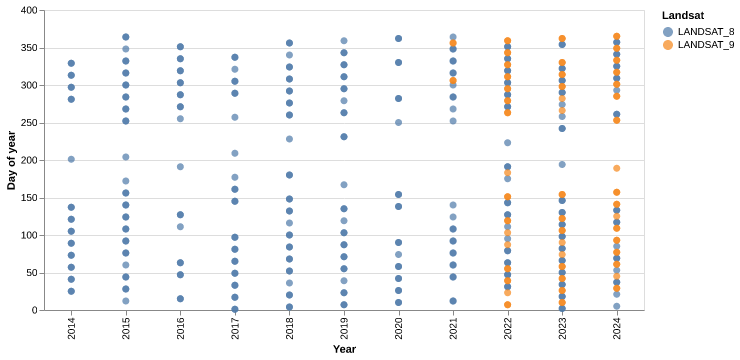

In [130]:
import altair as alt

# Sensor wise distribution of selected images
chart = alt.Chart(df).mark_point(size=50, filled=True).encode(
    x=alt.X('Year:O', title='Year'),
    y=alt.Y('DOY:Q', title='Day of year'),
    color=alt.Color(
        'satellite:N',
        legend=alt.Legend(title="Landsat")
    ),
    tooltip=[
        alt.Tooltip('Year:O', title='Year'),
        alt.Tooltip('DOY:Q', title='Day of year'),
        alt.Tooltip('satellite:N', title='Satellite type')
    ]
).properties(width=600, height=300)

chart


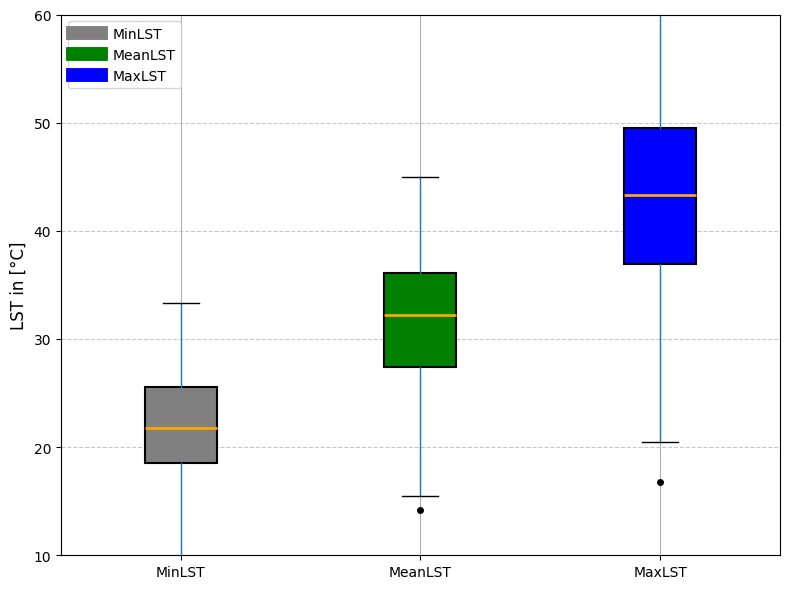

In [131]:
import matplotlib.pyplot as plt

# Select only the relevant columns
cols = ['MinLST', 'MeanLST', 'MaxLST']
df_plot = df_filtered[cols]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Custom boxplot
boxprops = dict(linestyle='-', linewidth=1.5)
medianprops = dict(color='orange', linewidth=2)
flierprops = dict(marker='o', markerfacecolor='black', markersize=4, linestyle='none')

colors = ['gray', 'green', 'blue']
bp = df_plot.boxplot(column=cols, ax=ax, boxprops=boxprops,
                     medianprops=medianprops, flierprops=flierprops,
                     patch_artist=True, return_type='dict')

# Apply colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Labels
ax.set_ylabel("LST in [°C]", fontsize=12)

# Grid
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Y-axis range
ax.set_ylim(10, 60)

# Legend
legend_labels = ['MinLST', 'MeanLST', 'MaxLST']
legend_handles = [plt.Line2D([0], [0], color=color, lw=10) for color in colors]
ax.legend(legend_handles, legend_labels, loc='upper left')

plt.tight_layout()
plt.show()

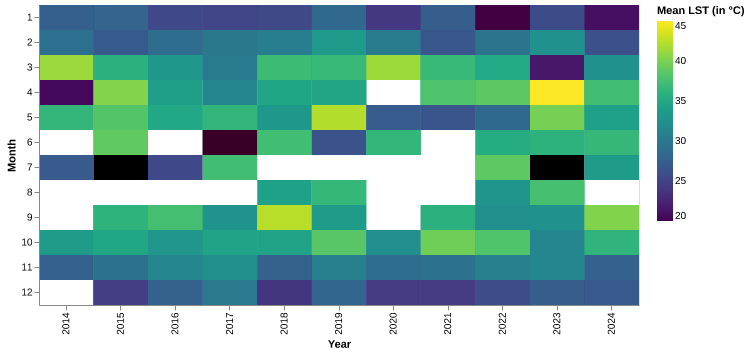

In [132]:
# mean LST calendar heatmap
alt.Chart(df).mark_rect().encode(
    x='Year:O',
    y='Month:O',
    color=alt.Color(
        'MeanLST:Q', title = 'Mean LST (in °C)', scale=alt.Scale(scheme='viridis', domain=(20,45 ))),
    tooltip=[
        alt.Tooltip('Year:O', title='Year'),
        alt.Tooltip('Month:O', title='Month'),
        alt.Tooltip('MeanLST:Q', title='LST')
    ]).properties(width=600, height=300)


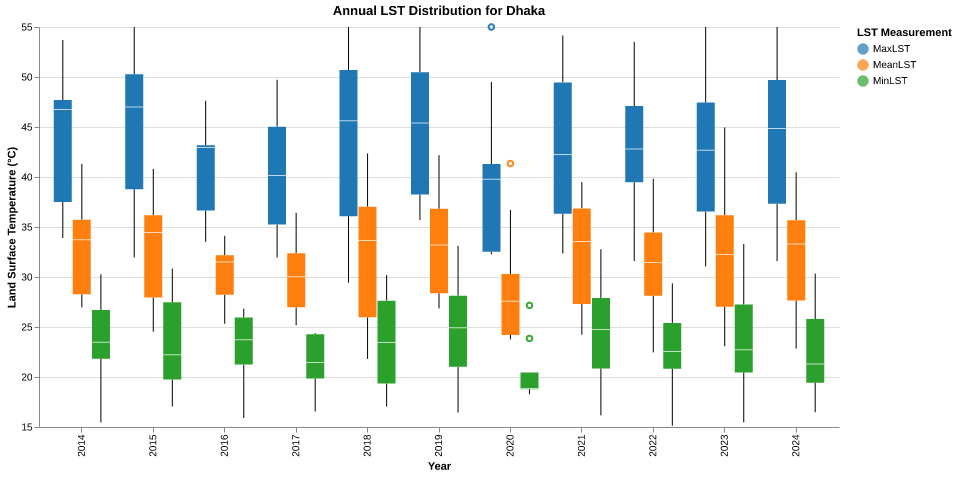

In [133]:
import altair as alt

# 1. Filter out unrealistic negative values (likely clouds/errors)
# We keep only records where the minimum temperature is above 15°C
df_filtered = df[df['MinLST'] > 15]

# 2. Melt the filtered dataframe
df_melted = df_filtered.melt(
    id_vars='Year',
    value_vars=['MinLST', 'MeanLST', 'MaxLST'],
    var_name='LST Type',
    value_name='Temperature'
)

# 3. Create the organized and cleaned boxplot
chart = alt.Chart(df_melted).mark_boxplot(
    size=18,
    extent=1.5,           # Standard whisker length
    outliers=True         # Set to False if you want to hide the dots entirely
).encode(
    x=alt.X('Year:O', title='Year'),

    # Use xOffset to group Min, Mean, and Max side-by-side
    xOffset='LST Type:N',

    y=alt.Y(
        'Temperature:Q',
        # Fixing the scale to a realistic Dhaka range (e.g., 15°C to 55°C)
        scale=alt.Scale(domain=[15, 55], clamp=True),
        title='Land Surface Temperature (°C)'
    ),

    color=alt.Color(
        'LST Type:N',
        scale=alt.Scale(scheme='category10'),
        legend=alt.Legend(title="LST Measurement")
    ),

    tooltip=[
        alt.Tooltip('Year:O'),
        alt.Tooltip('LST Type:N'),
        alt.Tooltip('Temperature:Q', format='.2f', title='Temp (°C)')
    ]
).properties(
    width=800,
    height=400,
    title='Annual LST Distribution for Dhaka'
).configure_view(
    stroke=None
)

chart

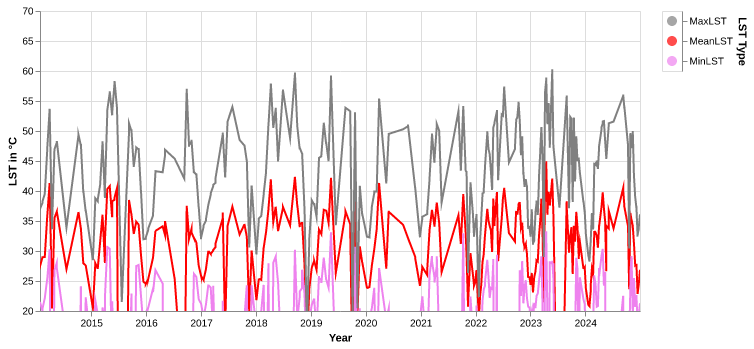

In [135]:
# LST trend
df_trend = df.interpolate()
base = alt.Chart(df_trend).encode(
    x=alt.X('Timestamp:T', title='Year'),
    tooltip=[
        alt.Tooltip('Timestamp:T', title='Year')
    ]
)

mean_line = base.mark_line(color='red').encode(
    y=alt.Y('MeanLST:Q', scale=alt.Scale(domain=[20, 70]), title='LST in °C'),
    tooltip=alt.Tooltip('MeanLST:Q'),
    color=alt.value('red')
)

min_line = base.mark_line(color='violet').encode(
    y=alt.Y('MinLST:Q', scale=alt.Scale(domain=[20, 70])),
    tooltip=alt.Tooltip('MinLST:Q'),
    color=alt.value('violet')
)

max_line = base.mark_line(color='grey').encode(
    y=alt.Y('MaxLST:Q', scale=alt.Scale(domain=[20, 70])),
    tooltip=alt.Tooltip('MaxLST:Q'),
    color=alt.value('grey')
)

chart = (mean_line + min_line + max_line).properties(width=600, height=300).interactive()

legend = alt.Chart(pd.DataFrame({
    'LST Type': ['MeanLST', 'MinLST', 'MaxLST'],
    'Color': ['red', 'violet', 'grey']
})).mark_circle(size=100).encode(
    y=alt.Y('LST Type:N', axis=alt.Axis(orient='right')),
    color=alt.Color('Color:N', scale=None, legend=None)
)

(chart | legend)



In [92]:
import json, shutil

# 1. NOTEBOOK NAME
src = "/content/drive/MyDrive/Untitled2.ipynb"
dst = src.replace(".ipynb", "_clean.ipynb")

# 2. Create clean copy
shutil.copy(src, dst)
print("Created clean copy:", dst)

# 3. Load notebook JSON
with open(dst, "r", encoding="utf-8") as f:
    nb = json.load(f)

# 4. Remove ONLY widget metadata (safe for plots)
def clean_widgets(obj):
    if isinstance(obj, dict):

        # Remove widget metadata at any level
        if "metadata" in obj and "widgets" in obj["metadata"]:
            obj["metadata"].pop("widgets", None)

        # Remove widget MIME types (but keep plot MIME types)
        if "data" in obj:
            obj["data"].pop("application/vnd.jupyter.widget-view+json", None)

        # Recurse
        for key in obj:
            clean_widgets(obj[key])

    elif isinstance(obj, list):
        for item in obj:
            clean_widgets(item)

clean_widgets(nb)

# 5. Clear output ONLY for installation cell(s)
cells_to_clear = [1]   # your pip install cell index

for idx in cells_to_clear:
    if idx < len(nb["cells"]):
        cell = nb["cells"][idx]
        if cell.get("cell_type") == "code":
            cell["outputs"] = []
            cell["execution_count"] = None
            print(f"Cleared output of cell {idx}")

# 6. Save cleaned notebook
with open(dst, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=2, ensure_ascii=False)

print("\nExport-ready clean notebook saved as:")
print(dst)


Created clean copy: /content/drive/MyDrive/Untitled2_clean.ipynb
Cleared output of cell 1

Export-ready clean notebook saved as:
/content/drive/MyDrive/Untitled2_clean.ipynb
